# Ames Housing — Exploratory Data Analysis

This notebook profiles the Ames dataset used by the `house-price-prediction` pipeline. It is meant to be read end-to-end: each section is kept short, each plot is annotated with a takeaway, and the closing cell summarises the modelling implications that drove decisions in `src/`.

**Contents**
1. Dataset overview
2. Target variable (`SalePrice`) — distribution & log transform
3. Correlation structure
4. Top numeric predictors
5. Categorical signal (neighborhood, quality)
6. Outliers & missingness
7. Key takeaways for modelling

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.loader import load_data

sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 140})

df = load_data()
df.shape

(1460, 81)

## 1. Dataset overview

1 460 rows × 81 columns, target = `SalePrice`. The dataset blends 38 numeric and 43 categorical descriptors of residential homes sold in Ames, Iowa between 2006 and 2010.

In [2]:
dtype_counts = df.dtypes.value_counts().rename('count').to_frame()
display(dtype_counts)
display(df.describe().T.head(10))

,count
str,43
int64,35
float64,3


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


19 columns have missing values; top 15:


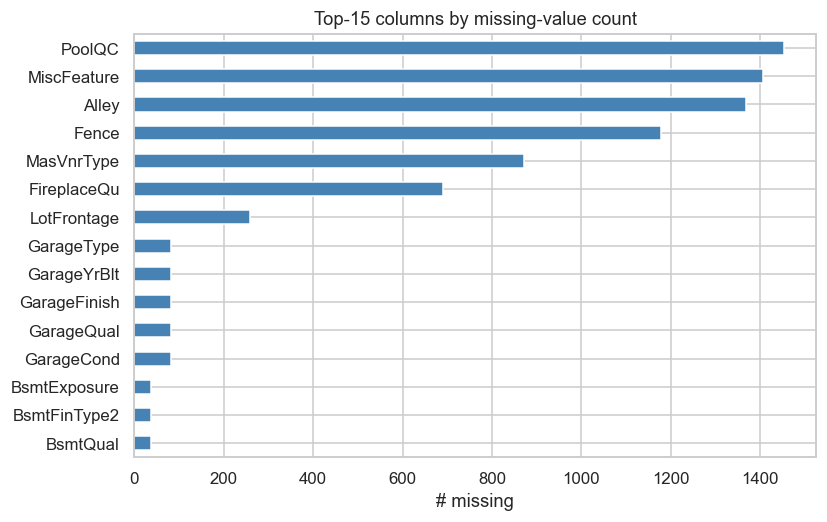

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'{len(missing)} columns have missing values; top 15:')
fig, ax = plt.subplots(figsize=(8, 5))
missing.head(15).iloc[::-1].plot.barh(ax=ax, color='steelblue')
ax.set(title='Top-15 columns by missing-value count', xlabel='# missing')
plt.show()

Missingness concentrates in five ‘feature-absent’ columns — `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `FireplaceQu`. These are structurally missing (the house has no pool, no alley, etc.) rather than noise, which motivates **treating NaN as its own category** for these fields (see `preprocessor.SimpleImputer(strategy='most_frequent')` + `add_indicator=True`).

## 2. Target variable — `SalePrice`

The raw target is heavily right-skewed; a log1p transform is standard practice and is what the pipeline uses during training. All RMSE numbers reported by the pipeline are therefore in **log dollars**.

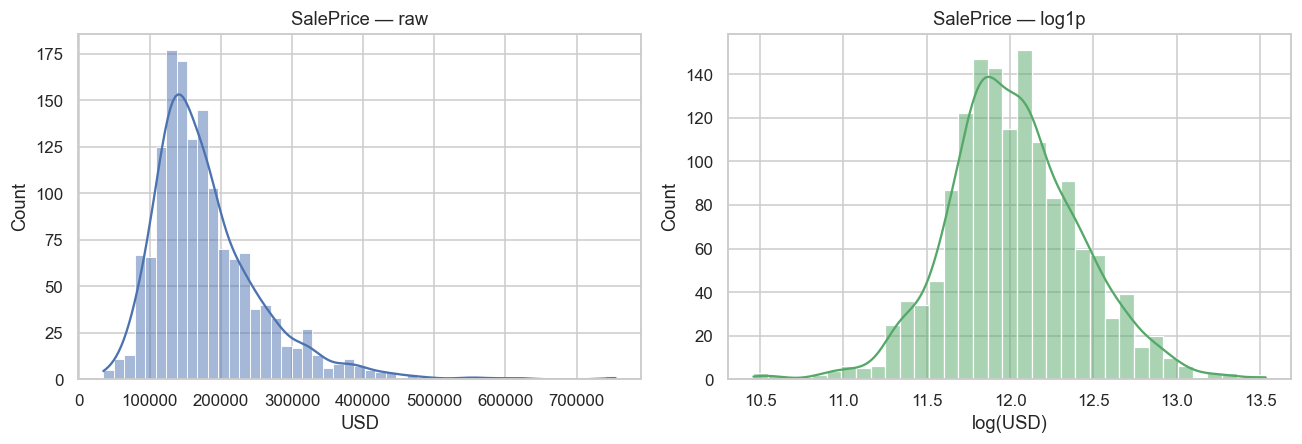

Skew raw:   1.883
Skew log1p: 0.121


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(df['SalePrice'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set(title='SalePrice — raw', xlabel='USD')
sns.histplot(np.log1p(df['SalePrice']), kde=True, ax=axes[1], color='#55A868')
axes[1].set(title='SalePrice — log1p', xlabel='log(USD)')
plt.tight_layout(); plt.show()

print(f"Skew raw:   {df['SalePrice'].skew():.3f}")
print(f"Skew log1p: {np.log1p(df['SalePrice']).skew():.3f}")

Raw skew ≈ 1.88 → 0.12 after `log1p`. The same logic is applied column-wise to any *feature* with |skew| > 0.75 via `SkewedLogTransformer`.

## 3. Correlation structure

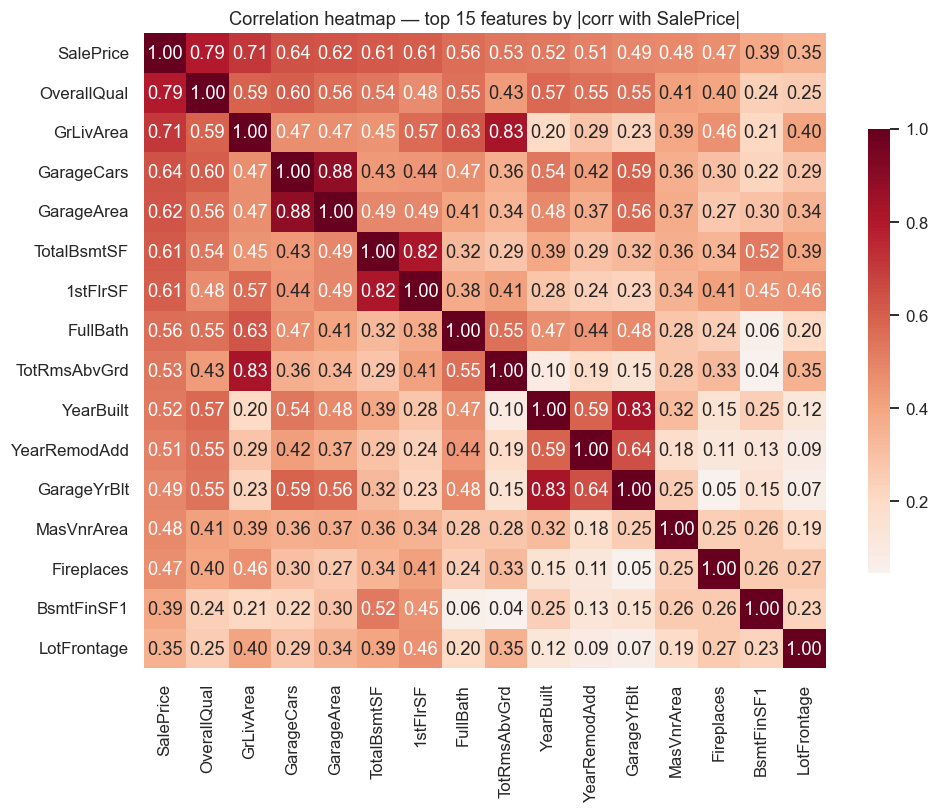

In [5]:
numeric = df.select_dtypes(include='number').copy()
corr = numeric.corr()
top15 = corr['SalePrice'].abs().sort_values(ascending=False).head(16).index
fig, ax = plt.subplots(figsize=(10, 7.5))
sns.heatmap(numeric[top15].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation heatmap — top 15 features by |corr with SalePrice|')
plt.show()

The strongest linear signals are `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars`/`GarageArea` (0.64 each), and `TotalBsmtSF` (0.61). Several pairs (`GarageCars`/`GarageArea`, `TotRmsAbvGrd`/`GrLivArea`, `1stFlrSF`/`TotalBsmtSF`) carry >0.8 mutual correlation — handled by `CorrelationThreshold` and by the domain feature `TotalSF` that collapses several of them.

## 4. Top numeric predictors

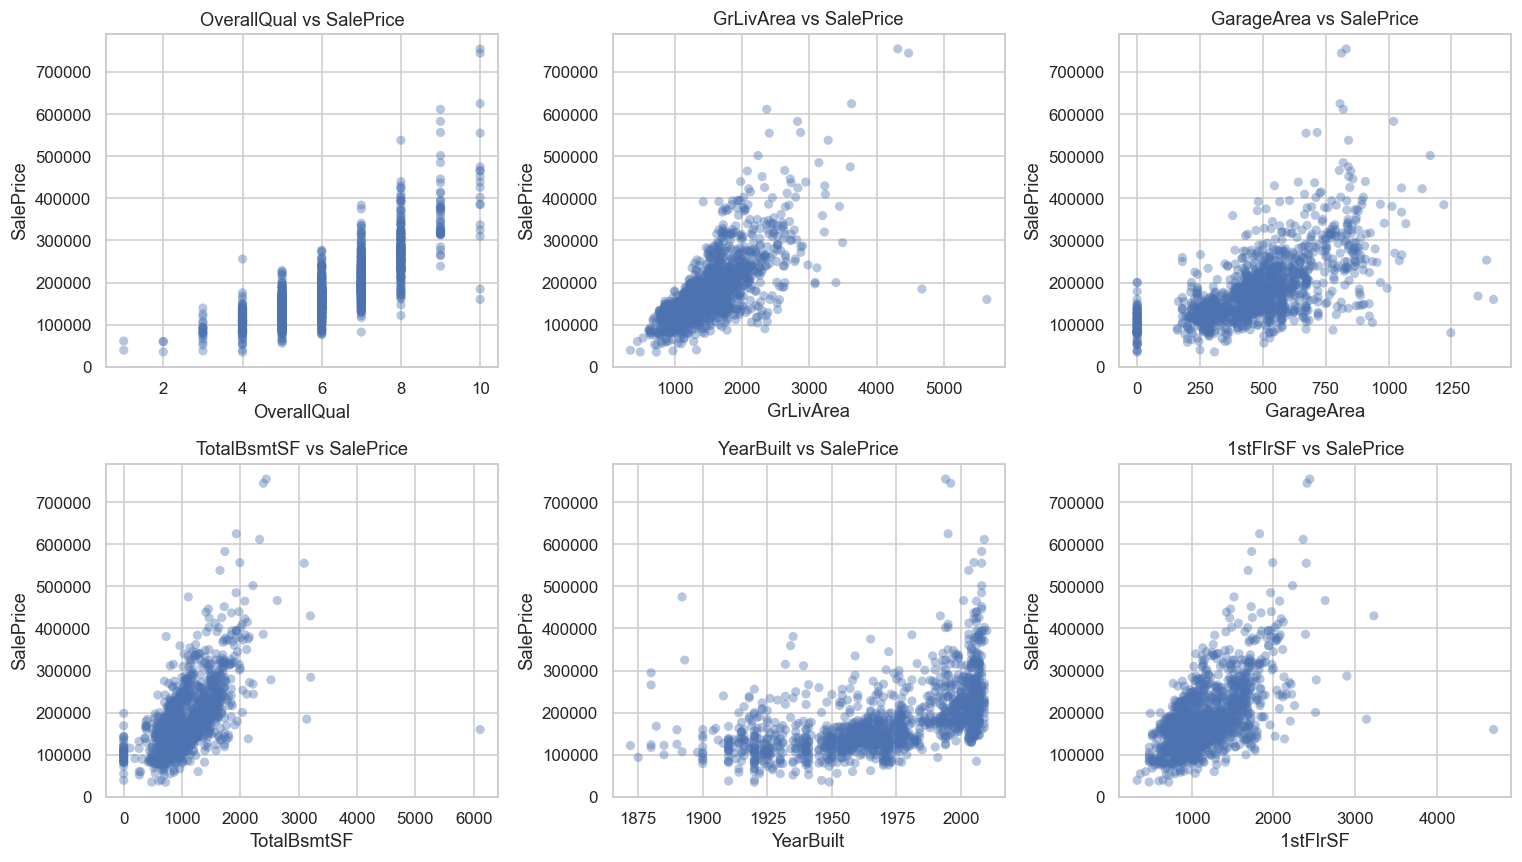

In [6]:
cols = ['OverallQual', 'GrLivArea', 'GarageArea', 'TotalBsmtSF',
        'YearBuilt', '1stFlrSF']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, c in zip(axes.flat, cols):
    sns.scatterplot(x=df[c], y=df['SalePrice'], ax=ax, alpha=0.4, edgecolor='none')
    ax.set(title=f'{c} vs SalePrice', ylabel='SalePrice')
plt.tight_layout(); plt.show()

`GrLivArea` shows two classic outliers (>4 000 sqft, sub-$200k) — the Ames paper flags these explicitly. The pipeline caps them via `IQROutlierCapper` rather than deleting rows.

## 5. Categorical signal

C:\Users\walki\AppData\Local\Temp\ipykernel_14644\638941251.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[1], palette='viridis')


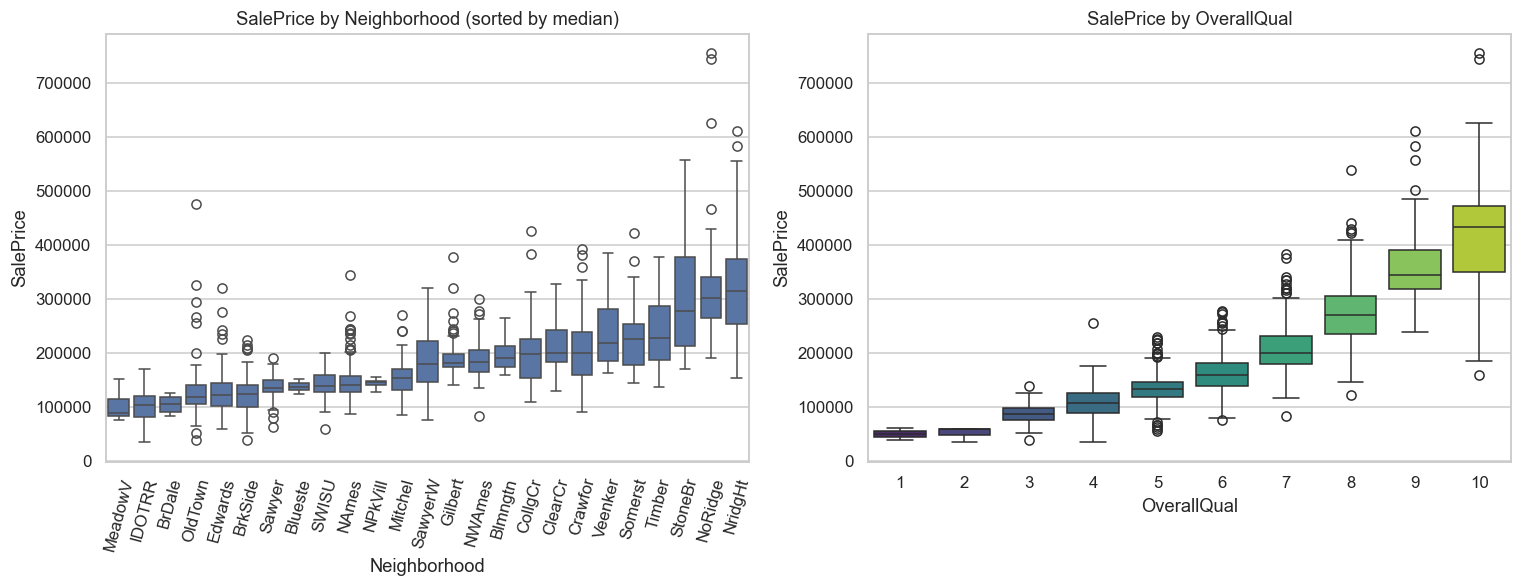

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
order = df.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order, ax=axes[0])
axes[0].tick_params(axis='x', rotation=75)
axes[0].set(title='SalePrice by Neighborhood (sorted by median)')

sns.boxplot(data=df, x='OverallQual', y='SalePrice', ax=axes[1], palette='viridis')
axes[1].set(title='SalePrice by OverallQual')
plt.tight_layout(); plt.show()

Neighborhood medians span **~3×** (Meadow Village → Stone Brook). Combined with the strong monotonic `OverallQual` signal, a tree-based model is a natural fit — hence Gradient Boosting / XGBoost / LightGBM in the catalogue.

## 6. Outliers & missingness pattern

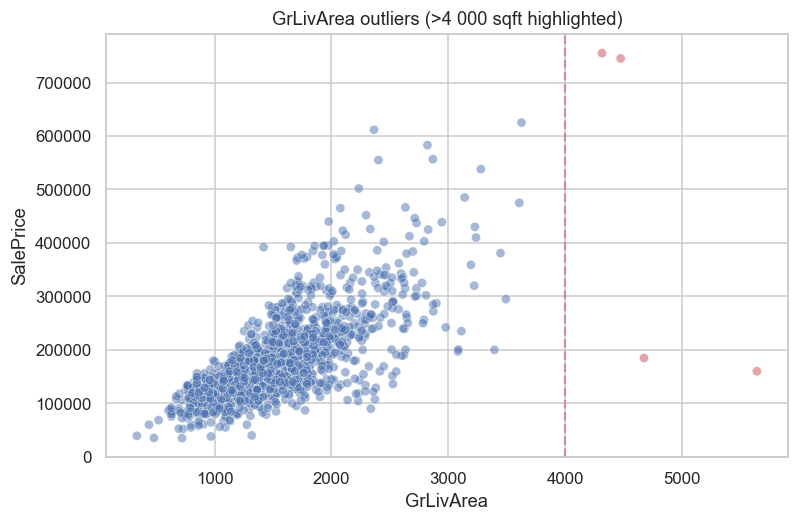

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x='GrLivArea', y='SalePrice',
                hue=(df['GrLivArea'] > 4000), ax=ax, alpha=0.5,
                palette={True: '#C44E52', False: '#4C72B0'}, legend=False)
ax.axvline(4000, color='#C44E52', linestyle='--', alpha=0.5)
ax.set(title='GrLivArea outliers (>4 000 sqft highlighted)')
plt.show()

## 7. Key takeaways for modelling

| Finding | Pipeline response |
|---|---|
| Target is right-skewed (skew ≈ 1.88) | Train on `log1p(SalePrice)`; invert with `expm1` before reporting dollars. |
| Several numeric features have |skew| > 0.75 | `SkewedLogTransformer` log-transforms them column-wise. |
| Strong collinear clusters (garage area/cars, basement/1st floor) | `CorrelationThreshold` + engineered `TotalSF` / `TotalBath`. |
| Structural missingness (pool, alley, etc.) | `SimpleImputer(most_frequent, add_indicator=True)` preserves the signal of *absence*. |
| A few extreme `GrLivArea` outliers | `IQROutlierCapper` at 3 × IQR rather than row-deletion. |
| Strong categorical effect (Neighborhood, OverallQual) | Tree-based models (RF, GBM, XGBoost, LightGBM) + stacked ensemble. |
| Highly non-linear feature interactions (age × quality, size × condition) | Polynomial expansion on top-K correlated features + domain interactions in `AmesInteractionFeatures`. |

See `src/pipeline.py` for the final ordering of steps.